# Target Visibility

Calculate the nightly altitude and annual dark-time visibility of TOI-1233 from the TÜBİTAK National Observatory. TDpy performs the coordinate transformations and writes the figure.

In [1]:
from IPython.display import Image, display

from tdpy.astro import run_target_visibility_diagnostic
from tdpy.paths import get_repository_path
from tdpy.verbosity import print as narrate

## Configure the Target and Observatory

Coordinates and site properties carry explicit physical units.

In [2]:
target = {
    "target_label": "TOI-1233",
    "right_ascension_degrees": 186.574,  # [deg]
    "declination_degrees": -51.363,  # [deg]
}
observatory = {
    "observatory_label": "TUG",
    "latitude_degrees": 36.824166,  # [deg]
    "longitude_degrees": 30.335555,  # [deg]
    "height_meters": 2500.0,  # [m]
    "utc_offset_hours": 3.0,  # [hour]
}
output_path = (
    get_repository_path()
    / "examples"
    / "target_visibility"
    / "visuals"
    / "target_visibility_toi-1233.png"
)

## Run TDpy

The shared diagnostic calculates both time baselines and generates the visibility figure.

Annual samples: 53


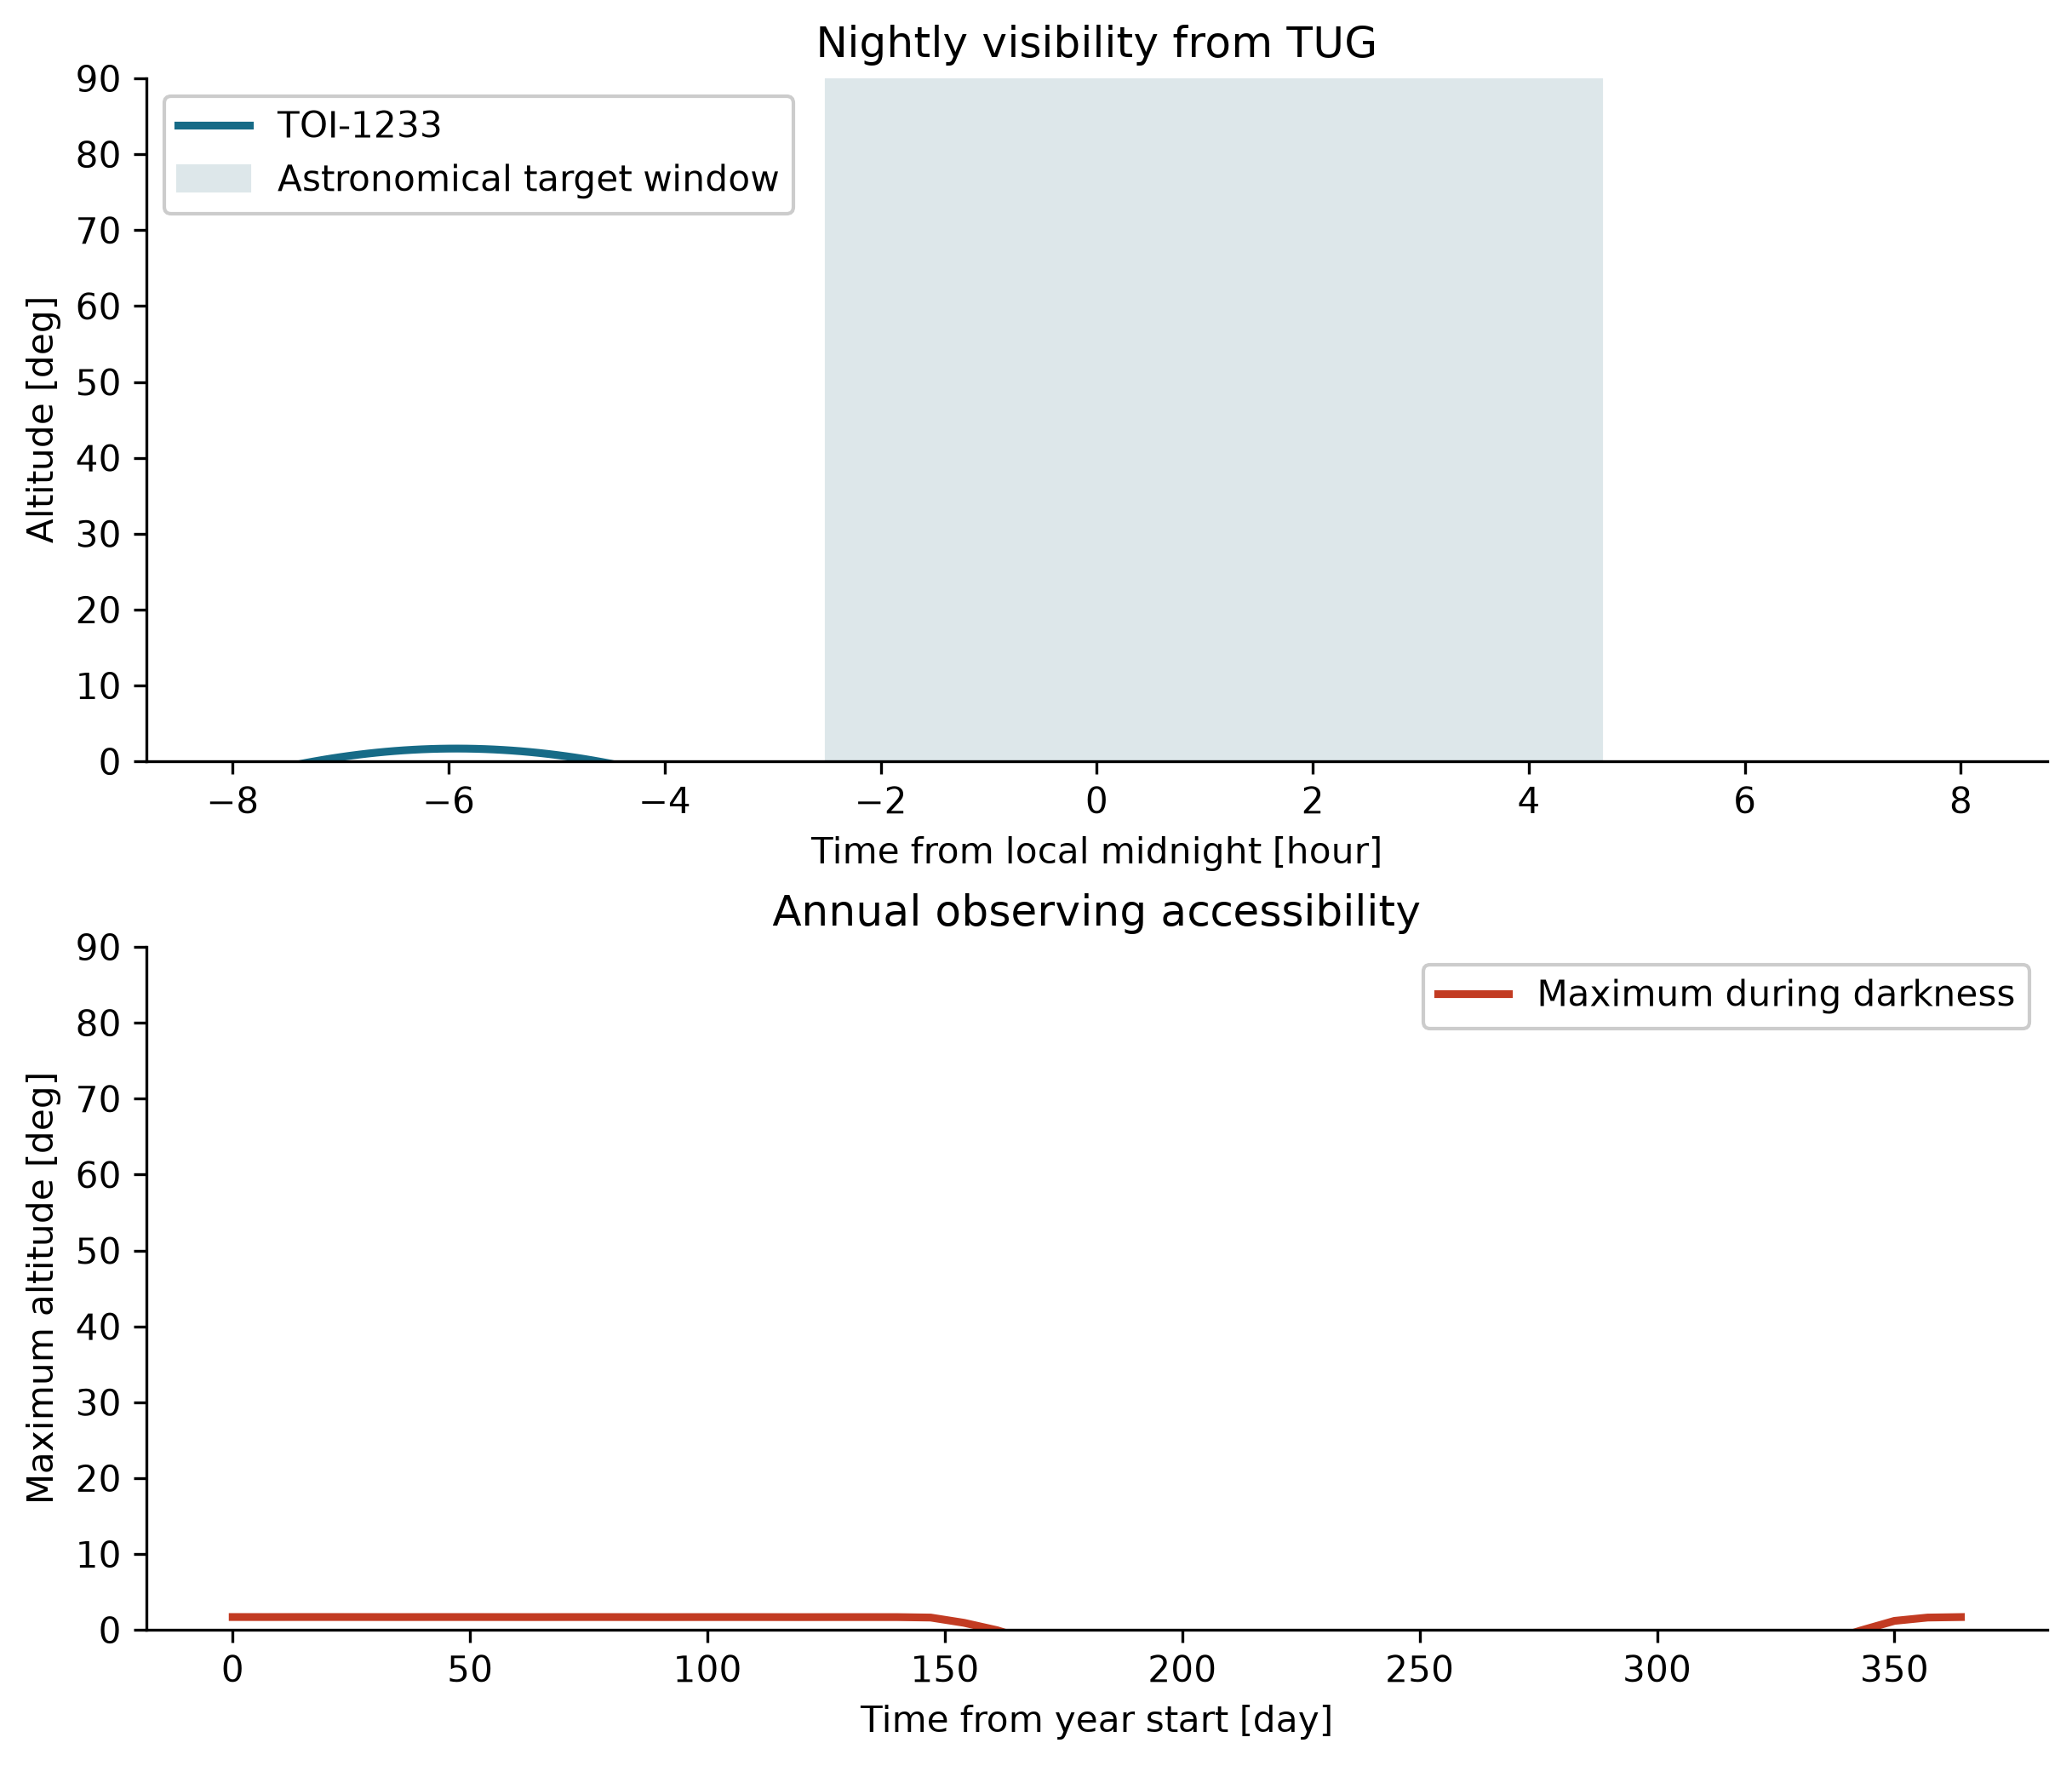

In [3]:
result = run_target_visibility_diagnostic(
    output_path=output_path,
    **target,
    **observatory,
    night="2022-07-13 00:00:00",
    year_start="2022-01-01 00:00:00",
)
print(f"Annual samples: {result.days_from_year_start.size}")
narrate(f"Reading from {output_path}...")
display(Image(filename=str(output_path)))